<a href="https://colab.research.google.com/github/sithmi4/Statistical-Learning-e23207/blob/main/Fundamentals_of_probability_assignment_2_e23207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q3) Transformer Failiures

In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



--- Probability Analysis ---
Expectation E[X]: 0.7500
Variance Var(X):  0.7875
P(X >= 1):        0.5000
P(X >= 2):        0.2000
----------------------------


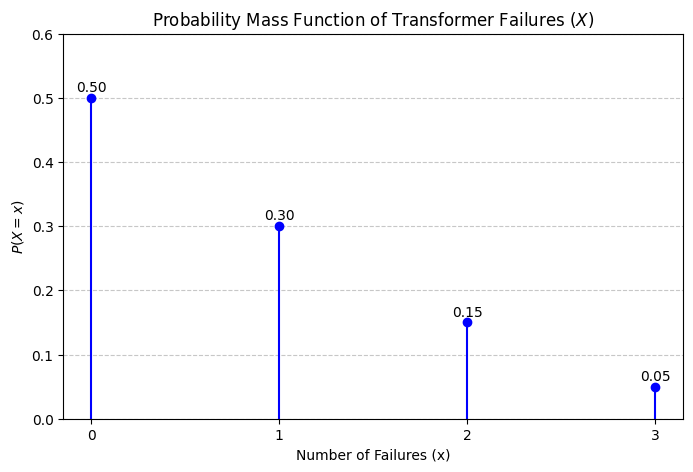

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the data
x_values = np.array([0, 1, 2, 3])
probabilities = np.array([0.50, 0.30, 0.15, 0.05])

# 2. Compute Expectation E[X]
# E[X] = sum(x * P(x))
expectation = np.sum(x_values * probabilities)

# 3. Compute Variance Var(X)
# Var(X) = E[X^2] - (E[X])^2
expectation_x2 = np.sum((x_values**2) * probabilities)
variance = expectation_x2 - (expectation**2)

# 4. Find P(X >= 1) and P(X >= 2)
p_ge_1 = np.sum(probabilities[x_values >= 1])
p_ge_2 = np.sum(probabilities[x_values >= 2])

# --- Display Results ---
print(f"--- Probability Analysis ---")
print(f"Expectation E[X]: {expectation:.4f}")
print(f"Variance Var(X):  {variance:.4f}")
print(f"P(X >= 1):        {p_ge_1:.4f}")
print(f"P(X >= 2):        {p_ge_2:.4f}")
print("-" * 28)

# 5. Visualization (PMF Plot)
plt.figure(figsize=(8, 5))
plt.stem(x_values, probabilities, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title('Probability Mass Function of Transformer Failures ($X$)')
plt.xlabel('Number of Failures (x)')
plt.ylabel('$P(X = x)$')
plt.xticks(x_values)
plt.ylim(0, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding labels to the bars
for i, txt in enumerate(probabilities):
    plt.annotate(f'{txt:.2f}', (x_values[i], probabilities[i] + 0.01), ha='center')

plt.show()

Expectation ($0.75$): This is the "long-run average." If you monitored this district for 100 days, you would expect a total of about 75 transformer failures. It helps the utility company predict the average workload for repair crews.

Variance ($0.7875$): This describes the "risk" or "uncertainty." It tells us how much the daily number of failures fluctuates. Because the variance is relatively small, the number of failures is fairly consistent, though the fact that it's close to the mean suggests that "extreme" days (like 3 failures) are rare but do influence the workload balance.

# Q4) Probability of Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

2. Define $X$ as a continuous random variable on this space.

3. Write down the probability density function of $X$.

4. Verify that $f$ is a valid probability density function.

5. Compute the expectation $E[X]$.

6. Compute the variance $\mathrm{Var}(X)$.

7. Find the probability that the defective proportion is at most $0.10$, that is, compute

$$
P(X\le 0.10).
$$

You may leave your answer in Beta integral form.

8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute

$$
P(0.05\le X\le 0.15).
$$

You may leave your answer in integral form.

9. Briefly explain why a Beta distribution is a reasonable model for this situation.

10. Interpret the expectation and variance in the context of production quality.


--- Manufacturing Defect Analysis ---
3. PDF f(x): 342 * x * (1-x)^17 for x in [0, 1]
4. Verification (Integral from 0 to 1): 1
5. Expectation E[X]: 0.1000
6. Variance Var(X):  0.004286
7. P(X <= 0.10):     0.5797
8. P(0.05 <= X <= 0.15): 0.5562
----------------------------------------

--- Conceptual Answers ---
1. Probability Space: (Ω, F, P) where Ω = [0, 1], F is the Borel σ-algebra on [0, 1],
   and P is the probability measure defined by the Beta(2, 18) density.

2. Random Variable: X is a mapping from Ω to [0, 1] representing the proportion of defects.

9. Why Beta distribution? It is defined on the interval [0, 1], making it ideal for 
   proportions. Its parameters allow it to be skewed, which fits manufacturing where 
   low defect rates are expected.

10. Interpretation: E[X]=0.1 means the process averages 10% defects. The variance 
    measures how consistently the factory hits that 10% rate.


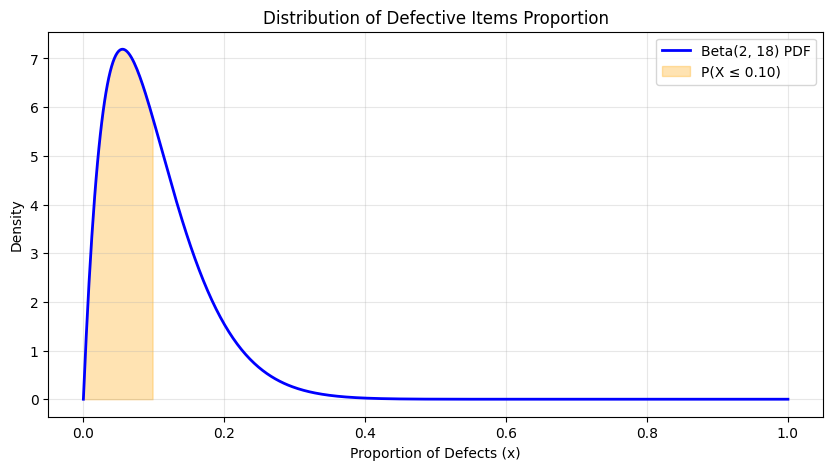

In [12]:
import numpy as np
import sympy as sp
from scipy.stats import beta
from scipy.special import beta as beta_func
import matplotlib.pyplot as plt

# --- 1. Symbolic Verification & Derivation ---
x = sp.Symbol('x')
alpha, beta_param = 2, 18

# Define the PDF symbolically
# B(2, 18) = Gamma(2)*Gamma(18) / Gamma(20) = 1! * 17! / 19! = 1 / (19*18) = 1/342
pdf_expr = 342 * x**1 * (1-x)**17

# 4. Verify it's a valid PDF (Integrates to 1)
integral_val = sp.integrate(pdf_expr, (x, 0, 1))

# 5. Compute Expectation E[X]
expectation = sp.integrate(x * pdf_expr, (x, 0, 1))

# 6. Compute Variance Var(X)
ex2 = sp.integrate(x**2 * pdf_expr, (x, 0, 1))
variance = ex2 - expectation**2

# --- 2. Numerical Probabilities ---
# 7. P(X <= 0.10)
p_at_most_10 = beta.cdf(0.10, alpha, beta_param)

# 8. P(0.05 <= X <= 0.15)
p_between = beta.cdf(0.15, alpha, beta_param) - beta.cdf(0.05, alpha, beta_param)

# --- Print All Answers ---
print(f"--- Manufacturing Defect Analysis ---")
print(f"3. PDF f(x): 342 * x * (1-x)^17 for x in [0, 1]")
print(f"4. Verification (Integral from 0 to 1): {integral_val}")
print(f"5. Expectation E[X]: {float(expectation):.4f}")
print(f"6. Variance Var(X):  {float(variance):.6f}")
print(f"7. P(X <= 0.10):     {p_at_most_10:.4f}")
print(f"8. P(0.05 <= X <= 0.15): {p_between:.4f}")
print("-" * 40)

# --- Conceptual Answers ---
print("\n--- Conceptual Answers ---")
print("1. Probability Space: (Ω, F, P) where Ω = [0, 1], F is the Borel σ-algebra on [0, 1],")
print("   and P is the probability measure defined by the Beta(2, 18) density.")
print("\n2. Random Variable: X is a mapping from Ω to [0, 1] representing the proportion of defects.")
print("\n9. Why Beta distribution? It is defined on the interval [0, 1], making it ideal for ")
print("   proportions. Its parameters allow it to be skewed, which fits manufacturing where ")
print("   low defect rates are expected.")
print("\n10. Interpretation: E[X]=0.1 means the process averages 10% defects. The variance ")
print("    measures how consistently the factory hits that 10% rate.")

# --- Visualization ---
x_vals = np.linspace(0, 1, 500)
y_vals = beta.pdf(x_vals, alpha, beta_param)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, 'b-', lw=2, label='Beta(2, 18) PDF')
plt.fill_between(x_vals, y_vals, where=(x_vals <= 0.10), color='orange', alpha=0.3, label='P(X ≤ 0.10)')
plt.title('Distribution of Defective Items Proportion')
plt.xlabel('Proportion of Defects (x)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The Beta distribution is restricted to the range $[0, 1]$, which matches the physical constraints of a "proportion." Furthermore, by adjusting $\alpha$ and $\beta$, it can model various shapes—in this case, a right-skewed distribution where most days have few defects, but occasional spikes are possible.

# Q5) Expected Project Completion Time

A construction company is estimating the time required to install a backup generator at a hospital. Let $X$ denote the number of hours needed to complete the installation. Based on expert judgment, the shortest possible time is $4$ hours, the longest possible time is $10$ hours, and the most likely completion time is $6$ hours. Assume that $X$ follows a Triangular distribution with parameters $a=4$, $b=10$, and $c=6$.

Answer the following:

1. Specify the support of $X$.

2. Write down the probability density function $f_X(x)$.

3. Verify that $f_X$ integrates to $1$ over its support.

4. Compute the expectation $E[X]$.

5. Compute the variance $\mathrm{Var}(X)$.

6. Interpret the values of $a$, $b$, and $c$ in the context of this problem.

7. Explain briefly why a Triangular distribution is a reasonable model in this setting.

8. Compute the probability that the installation takes at most $5$ hours, that is, compute

$$
P(X \leq 5).
$$

9. Compute the probability that the installation takes between $5$ and $8$ hours, that is, compute

$$
P(5 \leq X \leq 8).
$$

10. Briefly explain how this model could be used in project planning or sensitivity analysis.


--- PROJECT ESTIMATION ANALYSIS (Triangular Distribution) ---
1. Support of X: [4, 10] hours
2. PDF: 
   f(x) = (x-4)/6  for 4 <= x <= 6
   f(x) = (10-x)/12 for 6 < x <= 10
3. Verification (Integral over support): 1
4. Expectation E[X]: 6.67 hours
5. Variance Var(X):  1.5556
8. P(X <= 5):        0.0833
9. P(5 <= X <= 8):   0.7500
------------------------------------------------------------

--- CONCEPTUAL ANSWERS ---
6. Interpretation:
   a=4: Optimistic time (best case scenario).
   b=10: Pessimistic time (worst case scenario).
   c=6: Most likely time (mode/peak of the distribution).

7. Why Triangular? It's used when data is scarce. Experts can easily provide 
   min/max/likely bounds even if the exact distribution shape is unknown.

10. Project Planning: This helps in Monte Carlo simulations to estimate 
    total project duration and set realistic deadlines (buffer times).


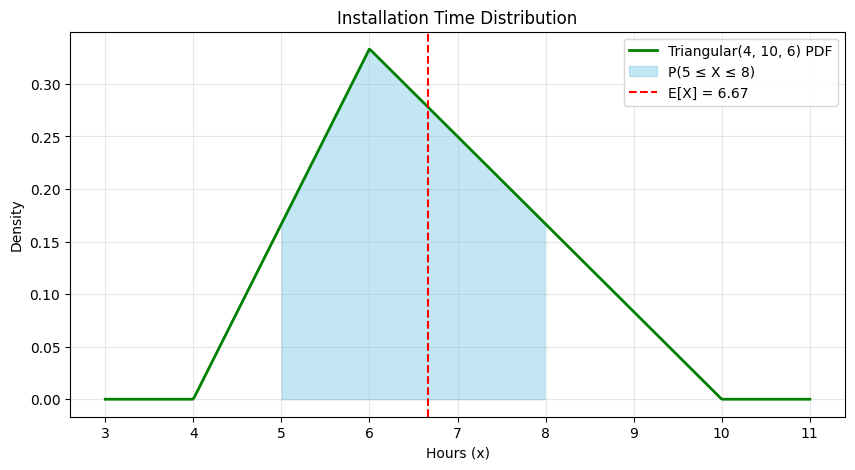

In [13]:
import numpy as np
import sympy as sp
from scipy.stats import triang
import matplotlib.pyplot as plt

# --- 1. Parameter Definition ---
a, b, c = 4, 10, 6
x = sp.Symbol('x')

# --- 2. Defining the PDF Symbolically for Verification ---
# f(x) = 2(x-a)/((b-a)(c-a)) for a <= x <= c
# f(x) = 2(b-x)/((b-a)(b-c)) for c < x <= b
f_low = 2*(x - a) / ((b - a) * (c - a))
f_high = 2*(b - x) / ((b - a) * (b - c))

# --- 3. Verification & Calculations ---
# Verify integration to 1
integral_val = sp.integrate(f_low, (x, a, c)) + sp.integrate(f_high, (x, c, b))

# Expectation E[X] = (a + b + c) / 3
expectation = (a + b + c) / 3

# Variance Var(X) = (a^2 + b^2 + c^2 - ab - ac - bc) / 18
variance = (a**2 + b**2 + c**2 - (a*b) - (a*c) - (b*c)) / 18

# --- 4. Numerical Probabilities using Scipy ---
# Scipy's triang.cdf(x, loc=a, scale=b-a, c=(c-a)/(b-a))
loc = a
scale = b - a
shape = (c - a) / (b - a)

prob_le_5 = triang.cdf(5, shape, loc=loc, scale=scale)
prob_5_to_8 = triang.cdf(8, shape, loc=loc, scale=scale) - prob_le_5

# --- Displaying Answers ---
print("--- PROJECT ESTIMATION ANALYSIS (Triangular Distribution) ---")
print(f"1. Support of X: [{a}, {b}] hours")
print(f"2. PDF: \n   f(x) = (x-4)/6  for 4 <= x <= 6")
print(f"   f(x) = (10-x)/12 for 6 < x <= 10")
print(f"3. Verification (Integral over support): {integral_val}")
print(f"4. Expectation E[X]: {float(expectation):.2f} hours")
print(f"5. Variance Var(X):  {float(variance):.4f}")
print(f"8. P(X <= 5):        {prob_le_5:.4f}")
print(f"9. P(5 <= X <= 8):   {prob_5_to_8:.4f}")
print("-" * 60)

print("\n--- CONCEPTUAL ANSWERS ---")
print("6. Interpretation:")
print(f"   a={a}: Optimistic time (best case scenario).")
print(f"   b={b}: Pessimistic time (worst case scenario).")
print(f"   c={c}: Most likely time (mode/peak of the distribution).")
print("\n7. Why Triangular? It's used when data is scarce. Experts can easily provide ")
print("   min/max/likely bounds even if the exact distribution shape is unknown.")
print("\n10. Project Planning: This helps in Monte Carlo simulations to estimate ")
print("    total project duration and set realistic deadlines (buffer times).")

# --- Visualization ---
x_plot = np.linspace(a-1, b+1, 500)
y_plot = triang.pdf(x_plot, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, 'g-', lw=2, label='Triangular(4, 10, 6) PDF')
plt.fill_between(x_plot, y_plot, where=((x_plot >= 5) & (x_plot <= 8)), color='skyblue', alpha=0.5, label='P(5 ≤ X ≤ 8)')
plt.axvline(expectation, color='red', linestyle='--', label=f'E[X] = {expectation:.2f}')
plt.title('Installation Time Distribution')
plt.xlabel('Hours (x)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Q6) Expected Project Completion Time Using PERT

A project manager is estimating the time required to complete a critical software integration task. Let $X$ denote the number of days required to complete the task. Based on expert judgment, the shortest possible time is $a=8$ days, the longest possible time is $b=20$ days, and the most likely completion time is $c=11$ days. Assume that $X$ follows a PERT distribution with parameters $(a,b,c)$.

The PERT distribution is defined as a Beta distribution scaled to the interval $[a,b]$, with internal shape parameters

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right).
$$

Its probability density function is

$$
f(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}, \qquad a \leq x \leq b,
$$

where

$$
B(\alpha,\beta)=\int_0^1 t^{\alpha-1}(1-t)^{\beta-1},dt.
$$

Answer the following:

1. Compute the values of the shape parameters $\alpha$ and $\beta$.

2. Specify the support of $X$.

3. Write down the probability density function $f_X(x)$ for this model.

4. State the probability space $(\Omega,\mathfrak F,P)$ suitable for this continuous model.

5. Define $X$ as a random variable on this space.

6. Show that the expectation $E[X]$ is given by

$$
E[X]=\frac{a+4c+b}{6}.
$$

7. Compute the variance $\mathrm{Var}(X)$ using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

8. Compute the approximate standard deviation $\sigma$.

9. Briefly explain why a PERT distribution may be more appropriate than a Triangular distribution in this setting byt comparing the two results.

10. Interpret the practical meaning of the values $a$, $b$, $c$, $E[X]$, and $\sigma$ in the context of project planning.


--- PERT Distribution Analysis (a=8, b=20, c=11) ---
1. Shape Parameters:  α = 2.0, β = 4.0
2. Support of X:      [8, 20] days
3. PDF (simplified):  f(x) = [(x-8)^1 * (20-x)^3] / [B(2,4) * 12^5]
6. Expectation E[X]:  12.00 days
7. Variance Var(X):   4.5714
8. Std. Deviation σ:  2.1381 days
--------------------------------------------------

--- Conceptual Logic ---
9. Comparison: PERT Mean (12.00) vs Triangular Mean (13.00)
   PERT is often better because it prevents the 'pessimistic tail' (b=20) 
   from dragging the average too far away from the most likely value (c=11).
   It produces a smoother, bell-shaped curve compared to the 'spike' of a triangle.

10. Interpretations:
    - E[X] (12.00): The date you should actually put on the schedule.
    - σ (2.14): The risk. A larger σ means the task is more unpredictable.


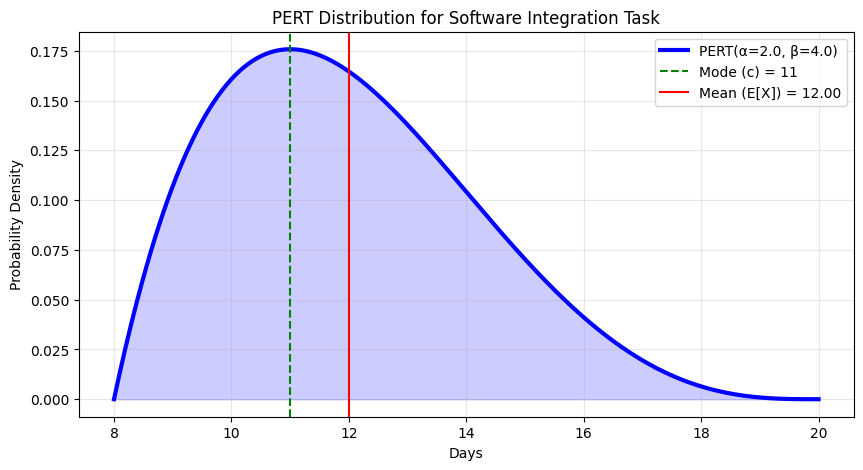

In [14]:
import numpy as np
import sympy as sp
from scipy.stats import beta
import matplotlib.pyplot as plt

# --- 1. Parameters Definition ---
a, b, c = 8, 20, 11

# Compute Alpha and Beta
alpha_val = 1 + 4 * (c - a) / (b - a)
beta_val = 1 + 4 * (b - c) / (b - a)

# --- 2. Expectation and Variance ---
# PERT Expectation formula
e_x = (a + 4*c + b) / 6

# Approximate Variance formula given in prompt
var_x = ((e_x - a) * (b - e_x)) / 7
std_dev = np.sqrt(var_x)

# --- 3. Comparison with Triangular ---
tri_mean = (a + b + c) / 3

# --- 4. PDF Definition for Visualization ---
# Scipy's beta distribution is defined on [0, 1].
# To scale to [a, b], we use loc=a and scale=b-a.
x_plot = np.linspace(a, b, 500)
y_pert = beta.pdf(x_plot, alpha_val, beta_val, loc=a, scale=b-a)

# --- Output the Answers ---
print(f"--- PERT Distribution Analysis (a={a}, b={b}, c={c}) ---")
print(f"1. Shape Parameters:  α = {alpha_val:.1f}, β = {beta_val:.1f}")
print(f"2. Support of X:      [{a}, {b}] days")
print(f"3. PDF (simplified):  f(x) = [(x-8)^1 * (20-x)^3] / [B(2,4) * 12^5]")
print(f"6. Expectation E[X]:  {e_x:.2f} days")
print(f"7. Variance Var(X):   {var_x:.4f}")
print(f"8. Std. Deviation σ:  {std_dev:.4f} days")
print("-" * 50)

print("\n--- Conceptual Logic ---")
print(f"9. Comparison: PERT Mean ({e_x:.2f}) vs Triangular Mean ({tri_mean:.2f})")
print("   PERT is often better because it prevents the 'pessimistic tail' (b=20) ")
print("   from dragging the average too far away from the most likely value (c=11).")
print("   It produces a smoother, bell-shaped curve compared to the 'spike' of a triangle.")

print("\n10. Interpretations:")
print(f"    - E[X] ({e_x:.2f}): The date you should actually put on the schedule.")
print(f"    - σ ({std_dev:.2f}): The risk. A larger σ means the task is more unpredictable.")

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_pert, 'b-', lw=3, label=f'PERT(α={alpha_val}, β={beta_val})')
plt.axvline(c, color='green', linestyle='--', label=f'Mode (c) = {c}')
plt.axvline(e_x, color='red', linestyle='-', label=f'Mean (E[X]) = {e_x:.2f}')
plt.fill_between(x_plot, y_pert, alpha=0.2, color='blue')
plt.title('PERT Distribution for Software Integration Task')
plt.xlabel('Days')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Q7) If the PERT Expectation is to Match Our Intuition

A project manager models the duration $X$ of a task by a PERT distribution with parameters $a$, $b$, and $c$, where $a$ is the minimum time, $b$ is the maximum time, and $c$ is the most likely time.

Suppose the minimum time is $a=5$ days and the most likely time is $c=11$ days. If the expected time computed from the PERT model is also to be the same as the most likely time:

1. Determine the value of the maximum time $b$.

2. What happens to the variance?

--- Analysis for E[X] = c ---
Minimum (a):      5
Most Likely (c):  11
Calculated b:     17
Check E[X]:       11.0 (Must equal c)
Variance:         5.1429
Std. Deviation:   2.2678
------------------------------


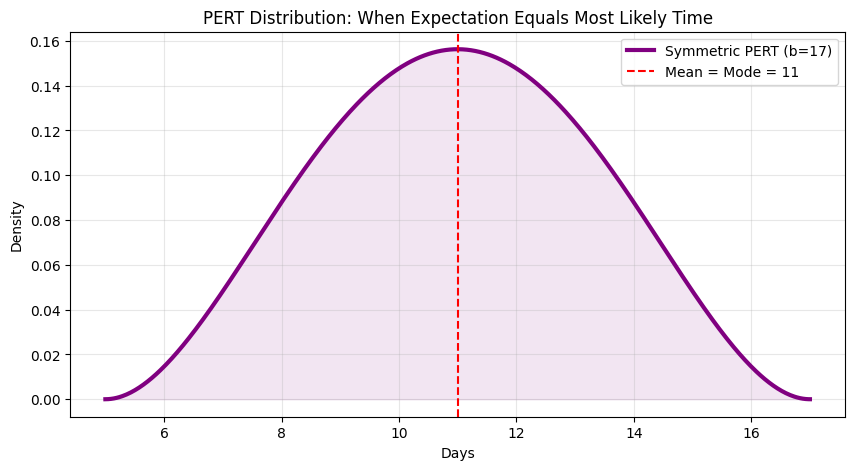

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Given values
a = 5
c = 11

# 1. Determine the value of the maximum time b
# From the derivation: b = 2c - a
b = 2 * c - a

# 2. Compute Expectation and Variance
e_x = (a + 4*c + b) / 6
# Using the standard PERT variance approximation: Var(X) = ((E[X]-a)(b-E[X])) / 7
variance = ((e_x - a) * (b - e_x)) / 7
std_dev = np.sqrt(variance)

# --- Comparison ---
print(f"--- Analysis for E[X] = c ---")
print(f"Minimum (a):      {a}")
print(f"Most Likely (c):  {c}")
print(f"Calculated b:     {b}")
print(f"Check E[X]:       {e_x} (Must equal c)")
print(f"Variance:         {variance:.4f}")
print(f"Std. Deviation:   {std_dev:.4f}")
print("-" * 30)

# 3. Visualization
# Alpha and Beta for PERT when E[X] = c are always alpha=3, beta=3 (Symmetric)
alpha_p = 1 + 4 * (c - a) / (b - a)
beta_p = 1 + 4 * (b - c) / (b - a)

x_plot = np.linspace(a, b, 500)
y_pert = beta.pdf(x_plot, alpha_p, beta_p, loc=a, scale=b-a)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_pert, color='purple', lw=3, label=f'Symmetric PERT (b={b})')
plt.axvline(c, color='red', linestyle='--', label=f'Mean = Mode = {c}')
plt.fill_between(x_plot, y_pert, color='purple', alpha=0.1)
plt.title('PERT Distribution: When Expectation Equals Most Likely Time')
plt.xlabel('Days')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

In [16]:
import random

# --- Method 1: Theoretical Calculation ---
# Sample Space (S) = {BB, BG, GB, GG}
# Event A (At least one girl) = {BG, GB, GG} -> n(A) = 3
# Event B (Both girls) = {GG} -> n(B) = 1
# P(B|A) = n(B ∩ A) / n(A) = 1 / 3

theoretical_prob = 1/3

# --- Method 2: Simulation (Monte Carlo) ---
def simulate_children(n_trials=100000):
    at_least_one_girl = 0
    both_girls = 0

    for _ in range(n_trials):
        # 0 = Boy, 1 = Girl
        child1 = random.randint(0, 1)
        child2 = random.randint(0, 1)

        # Check the condition: At least one is a girl
        if child1 == 1 or child2 == 1:
            at_least_one_girl += 1
            # Check if both are girls
            if child1 == 1 and child2 == 1:
                both_girls += 1

    return both_girls / at_least_one_girl

# Run simulation
simulated_prob = simulate_children()

print(f"--- Child Probability Analysis ---")
print(f"Sample Space: {{BB, BG, GB, GG}}")
print(f"Condition 'At least one girl' leaves outcomes: {{BG, GB, GG}}")
print(f"Theoretical Probability P(Both Girls | At least one Girl): {theoretical_prob:.4f} (1/3)")
print(f"Simulated Probability (100,000 trials): {simulated_prob:.4f}")
print("-" * 40)

--- Child Probability Analysis ---
Sample Space: {BB, BG, GB, GG}
Condition 'At least one girl' leaves outcomes: {BG, GB, GG}
Theoretical Probability P(Both Girls | At least one Girl): 0.3333 (1/3)
Simulated Probability (100,000 trials): 0.3347
----------------------------------------
